# USA Economy Analysis

## 04-exploratory-analysis: What patterns exist in the data?

## imports

In [267]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

## Load dataset

In [268]:
Path_Data = Path("../data/processed/")
df_economy = pd.read_csv(Path_Data/ "USA_economy.csv")

## Data overview

The final dataset contains 201 observations and 25 variables.

The dataset covers the period from 1974-01-01 to 2024-01-01 at a quarterly frequency.

The main economic variables analyzed in this notebook are GDP, CPI, and the unemployment rate, along with their growth or change measures.

The purpose of this exploratory analysis is to identify trends, fluctuations, distributions, and relationships among the main economic variables before conducting further economic analysis.

In [269]:
df_economy.head()

,year,quarter,year-quarter,gdp,cpi,unemployment_rate,gdp_growth,cpi_growth,unemployment_change,gdp_yoy,...,gdp_volatility_4q,cpi_volatility_4q,unemployment_volatility_4q,gdp_growth_lag1,gdp_growth_lag2,cpi_growth_lag1,unemployment_change_lag1,covid_flag,recession_flag,high_growth_flag
0,1974,1,1974Q1,1491.209,47.300000,5.133333,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
1,1974,2,1974Q2,1530.056,48.566667,5.200000,0.026051,0.026779,0.066667,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True
2,1974,3,1974Q3,1560.026,49.933333,5.633333,0.019588,0.028140,0.433333,NaN,...,NaN,NaN,NaN,0.026051,NaN,0.026779,0.066667,False,False,True
3,1974,4,1974Q4,1599.679,51.466667,6.600000,0.025418,0.030708,0.966667,NaN,...,NaN,NaN,NaN,0.019588,0.026051,0.028140,0.433333,False,False,True
4,1975,1,1975Q1,1616.116,52.566667,8.266667,0.010275,0.021373,1.666667,0.083762,...,0.007309,0.003937,0.695222,0.025418,0.019588,0.030708,0.966667,False,False,False


In [270]:
df_economy.columns

Index(['year', 'quarter', 'year-quarter', 'gdp', 'cpi', 'unemployment_rate',
       'gdp_growth', 'cpi_growth', 'unemployment_change', 'gdp_yoy', 'cpi_yoy',
       'unemployment_yoy_change', 'gdp_rolling_mean_4q', 'cpi_rolling_mean_4q',
       'unemployment_rolling_mean_4q', 'gdp_volatility_4q',
       'cpi_volatility_4q', 'unemployment_volatility_4q', 'gdp_growth_lag1',
       'gdp_growth_lag2', 'cpi_growth_lag1', 'unemployment_change_lag1',
       'covid_flag', 'recession_flag', 'high_growth_flag'],
      dtype='str')

In [271]:
df_economy.dtypes

year                              int64
quarter                           int64
year-quarter                        str
gdp                             float64
cpi                             float64
unemployment_rate               float64
gdp_growth                      float64
cpi_growth                      float64
unemployment_change             float64
gdp_yoy                         float64
cpi_yoy                         float64
unemployment_yoy_change         float64
gdp_rolling_mean_4q             float64
cpi_rolling_mean_4q             float64
unemployment_rolling_mean_4q    float64
gdp_volatility_4q               float64
cpi_volatility_4q               float64
unemployment_volatility_4q      float64
gdp_growth_lag1                 float64
gdp_growth_lag2                 float64
cpi_growth_lag1                 float64
unemployment_change_lag1        float64
covid_flag                         bool
recession_flag                     bool
high_growth_flag                   bool


In [272]:
df_economy.info()

<class 'pandas.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   year                          201 non-null    int64  
 1   quarter                       201 non-null    int64  
 2   year-quarter                  201 non-null    str    
 3   gdp                           201 non-null    float64
 4   cpi                           201 non-null    float64
 5   unemployment_rate             201 non-null    float64
 6   gdp_growth                    200 non-null    float64
 7   cpi_growth                    200 non-null    float64
 8   unemployment_change           200 non-null    float64
 9   gdp_yoy                       197 non-null    float64
 10  cpi_yoy                       197 non-null    float64
 11  unemployment_yoy_change       197 non-null    float64
 12  gdp_rolling_mean_4q           197 non-null    float64
 13  cpi_rolling_mean

In [273]:
df_economy.describe()

,year,quarter,gdp,cpi,unemployment_rate,gdp_growth,cpi_growth,unemployment_change,gdp_yoy,cpi_yoy,...,gdp_rolling_mean_4q,cpi_rolling_mean_4q,unemployment_rolling_mean_4q,gdp_volatility_4q,cpi_volatility_4q,unemployment_volatility_4q,gdp_growth_lag1,gdp_growth_lag2,cpi_growth_lag1,unemployment_change_lag1
count,201.000000,201.000000,201.000000,201.000000,201.000000,200.000000,200.000000,200.000000,197.000000,197.000000,...,197.000000,197.000000,198.000000,197.000000,197.000000,197.000000,199.000000,198.000000,199.000000,199.000000
mean,1998.626866,2.492537,10767.185687,167.480264,6.176783,0.014900,0.009471,-0.007167,0.060893,0.038202,...,0.014845,0.009355,6.202567,0.006861,0.003650,0.302906,0.014918,0.014930,0.009493,-0.007035
std,14.542526,1.123029,7074.040546,68.229280,1.748276,0.012701,0.008004,0.805362,0.033143,0.028462,...,0.007880,0.006813,1.634680,0.009340,0.002799,0.776061,0.012730,0.012762,0.008019,0.807391
min,1974.000000,1.000000,1491.209000,47.300000,3.500000,-0.082619,-0.022902,-4.200000,-0.068817,-0.016070,...,-0.016874,-0.003965,3.541667,0.000305,0.000281,0.031914,-0.082619,-0.082619,-0.022902,-4.200000
25%,1986.000000,1.000000,4607.669000,109.700000,4.900000,0.010253,0.005316,-0.200000,0.041883,0.019654,...,0.010423,0.004893,4.943750,0.003287,0.001808,0.091793,0.010232,0.010210,0.005352,-0.200000
50%,1999.000000,2.000000,9411.682000,164.733333,5.866667,0.013835,0.007909,-0.066667,0.057575,0.030735,...,0.014101,0.007597,5.920833,0.004549,0.002993,0.136083,0.013854,0.013863,0.007955,-0.066667
75%,2011.000000,3.000000,15647.680000,226.032667,7.333333,0.019137,0.011462,0.066667,0.074093,0.046259,...,0.018063,0.011371,7.337500,0.006710,0.004569,0.237268,0.019146,0.019155,0.011465,0.066667
max,2024.000000,4.000000,28269.174000,309.685000,13.000000,0.087103,0.039456,9.166667,0.169698,0.144258,...,0.040319,0.034268,10.266667,0.070291,0.018092,5.909001,0.087103,0.087103,0.039456,9.166667


## Time series overview

The dataset covers the period from 1974-01-01 to 2024-01-01.

The observations are ordered chronologically, allowing the main economic variables to be examined as quarterly time series.

Using a quarterly frequency makes it possible to observe both long-term trends and shorter-term fluctuations in the U.S. economy.

In [274]:
df_economy["year-quarter"].min()

'1974Q1'

In [275]:
df_economy["year-quarter"].max()

'2024Q1'

In [276]:
df_economy["year-quarter"].is_monotonic_increasing

True

## Set index

In [277]:
df_economy = df_economy.set_index("year-quarter")

## Univariate analysis

### GDP

#### GDP line plot by year

The GDP series shows an overall increasing trend over the sample period.

Although the long-term trend is increasing, several periods show noticeable deviations from the general pattern.

These fluctuations become more apparent when GDP growth, rather than the GDP level itself, is examined.

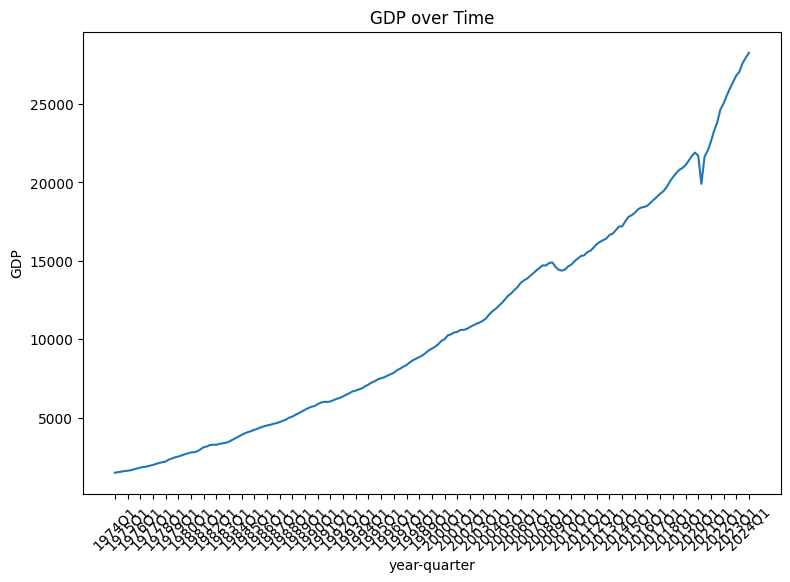

In [278]:
plt.figure(figsize=(9,6))
plt.plot(df_economy.index, df_economy["gdp"])
plt.title("GDP over Time")
plt.xlabel("year-quarter")
plt.xticks(
    range(0, len(df_economy.index), 4),
    df_economy.index[::4],
    rotation=45
)
plt.ylabel("GDP")
plt.show()

#### GDP growth line plot by year

GDP growth fluctuates around 0.025 over the sample period.

The series contains periods of positive/negative growth, with particularly notable changes occurring around 2020.

The largest decrease in GDP growth occurs around 2020Q1, while the largest increase occurs around 2020Q3.

These observations suggest that economic growth has not been constant and that some periods experienced substantially greater fluctuations than others.

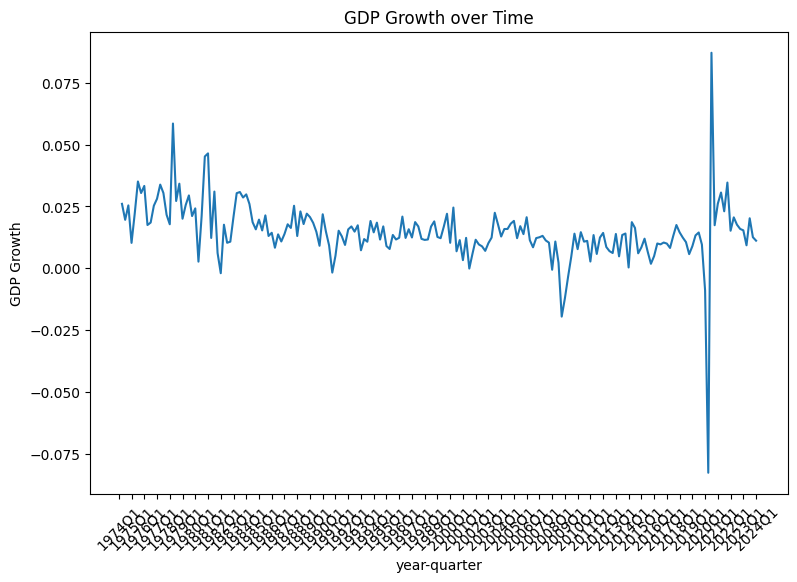

In [279]:
plt.figure(figsize=(9,6))
plt.plot(df_economy.index,df_economy["gdp_growth"])
plt.title("GDP Growth over Time")
plt.xlabel("year-quarter")
plt.ylabel("GDP Growth")
plt.xticks(
    range(0, len(df_economy.index), 4),
    df_economy.index[::4],
    rotation=45
)
plt.show()

#### GDP highs and lows

In [280]:
df_economy["gdp_growth"].nsmallest()

year-quarter
2020Q2   -0.082619
2008Q4   -0.019517
2009Q1   -0.012137
2020Q1   -0.008943
2009Q2   -0.003442
Name: gdp_growth, dtype: float64

In [281]:
df_economy["gdp_growth"].nlargest()

year-quarter
2020Q3    0.087103
1978Q2    0.058505
1981Q1    0.046440
1980Q4    0.045186
1975Q3    0.035092
Name: gdp_growth, dtype: float64

#### Descriptive statistics

In [282]:
df_economy["gdp"].describe()

count      201.000000
mean     10767.185687
std       7074.040546
min       1491.209000
25%       4607.669000
50%       9411.682000
75%      15647.680000
max      28269.174000
Name: gdp, dtype: float64

In [283]:
df_economy["gdp_growth"].describe()

count    200.000000
mean       0.014900
std        0.012701
min       -0.082619
25%        0.010253
50%        0.013835
75%        0.019137
max        0.087103
Name: gdp_growth, dtype: float64

#### boxplot

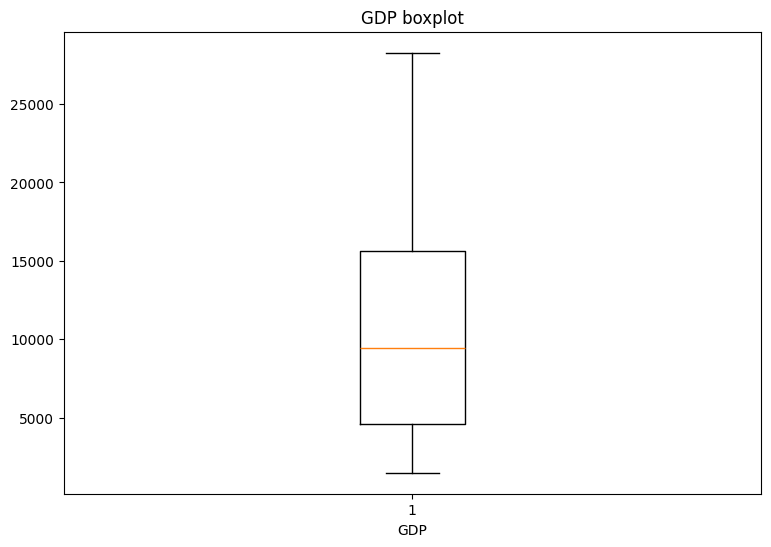

In [284]:
plt.figure(figsize=(9,6))
plt.boxplot(df_economy["gdp"])
plt.xlabel("GDP")
plt.title("GDP boxplot")
plt.show()

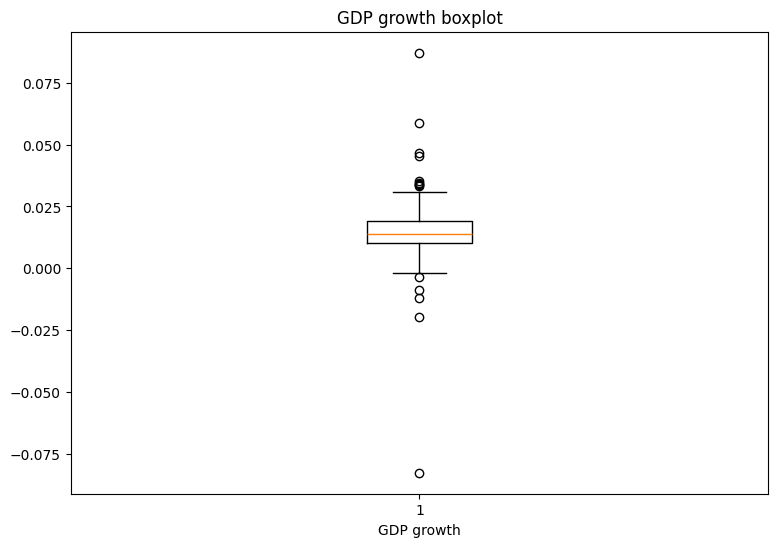

In [285]:
plt.figure(figsize=(9,6))
plt.boxplot(df_economy["gdp_growth"].dropna())
plt.xlabel("GDP growth")
plt.title("GDP growth boxplot")
plt.show()

### CPI

#### CPI by year

The CPI series shows a generally increasing trend over the sample period.

This indicates that the overall price level has gone up throughout the years.

However, examining CPI growth provides a clearer picture of changes in the pace of price increases.

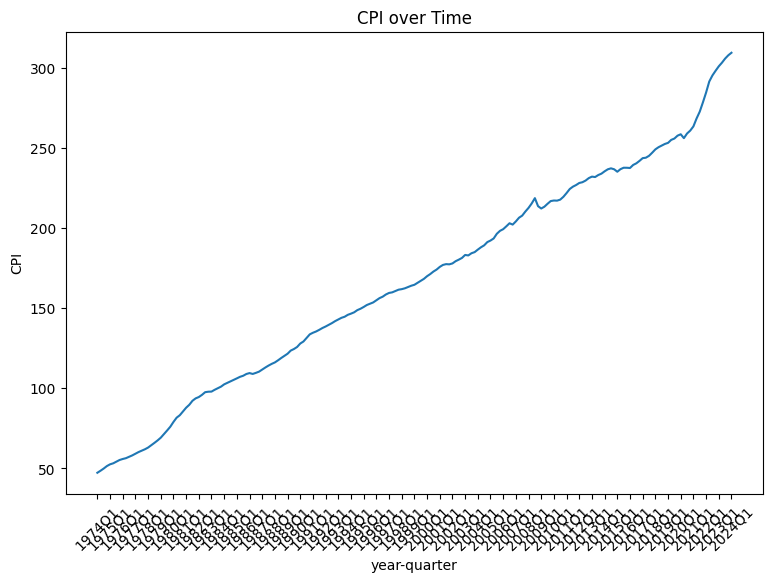

In [286]:
plt.figure(figsize=(9,6))
plt.plot(df_economy.index, df_economy["cpi"])
plt.title("CPI over Time")
plt.xlabel("year-quarter")
plt.ylabel("CPI")
plt.xticks(
    range(0, len(df_economy.index), 4),
    df_economy.index[::4],
    rotation=45
)
plt.show()

#### CPI Growth by year

CPI growth shows very variant pattern over time.

The largest increases in CPI growth occur around 1978Q1, while the lowest observations occur around 2008Q1.

These periods may represent episodes of unusually strong or weak price growth and will be useful to examine further.

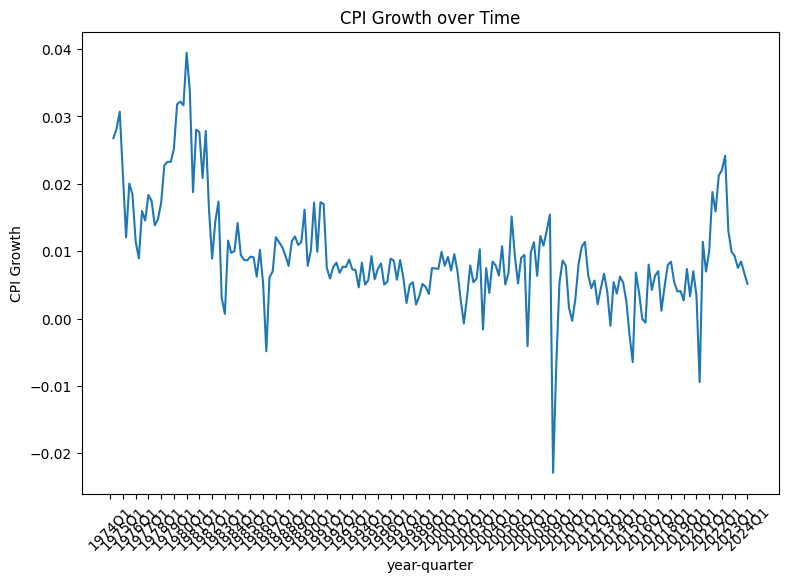

In [287]:
plt.figure(figsize=(9,6))
plt.plot(df_economy.index, df_economy["cpi_growth"])
plt.title("CPI Growth over Time")
plt.xlabel("year-quarter")
plt.ylabel("CPI Growth")
plt.xticks(
    range(0, len(df_economy.index), 4),
    df_economy.index[::4],
    rotation=45
)
plt.show()

#### CPI highs and lows

In [288]:
df_economy["cpi_growth"].nsmallest()

year-quarter
2008Q4   -0.022902
2020Q2   -0.009434
2009Q1   -0.006879
2015Q1   -0.006473
1986Q2   -0.004868
Name: cpi_growth, dtype: float64

In [289]:
df_economy["cpi_growth"].nlargest()

year-quarter
1980Q1    0.039456
1980Q2    0.033741
1979Q3    0.032213
1979Q2    0.031792
1979Q4    0.031660
Name: cpi_growth, dtype: float64

#### Descriptive statistics

In [290]:
df_economy["cpi"].describe()

count    201.000000
mean     167.480264
std       68.229280
min       47.300000
25%      109.700000
50%      164.733333
75%      226.032667
max      309.685000
Name: cpi, dtype: float64

In [291]:
df_economy["cpi_growth"].describe()

count    200.000000
mean       0.009471
std        0.008004
min       -0.022902
25%        0.005316
50%        0.007909
75%        0.011462
max        0.039456
Name: cpi_growth, dtype: float64

#### Boxplot

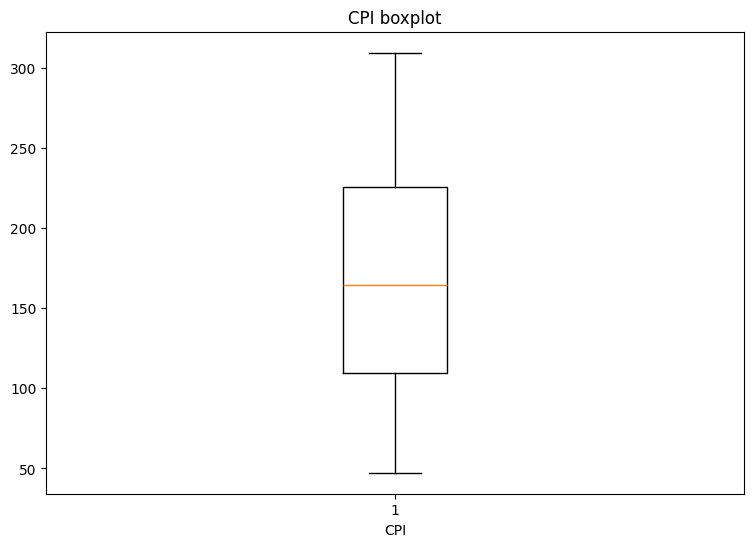

In [292]:
plt.figure(figsize=(9,6))
plt.boxplot(df_economy["cpi"])
plt.title("CPI boxplot")
plt.xlabel("CPI")
plt.show()

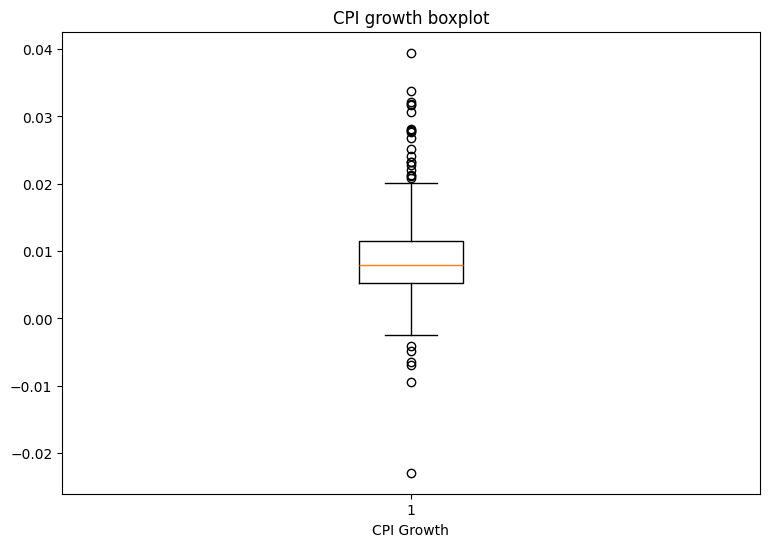

In [293]:
plt.figure(figsize=(9,6))
plt.boxplot(df_economy["cpi_growth"].dropna())
plt.title("CPI growth boxplot")
plt.xlabel("CPI Growth")
plt.show()

### Unemployment

#### Unemployment rate by year

The unemployment rate exhibits a cyclical pattern over the sample period.

Several periods show noticeable increases or decreases in unemployment.

The most pronounced movements occur around 2020, suggesting that changes in labor market conditions vary considerably across the sample.

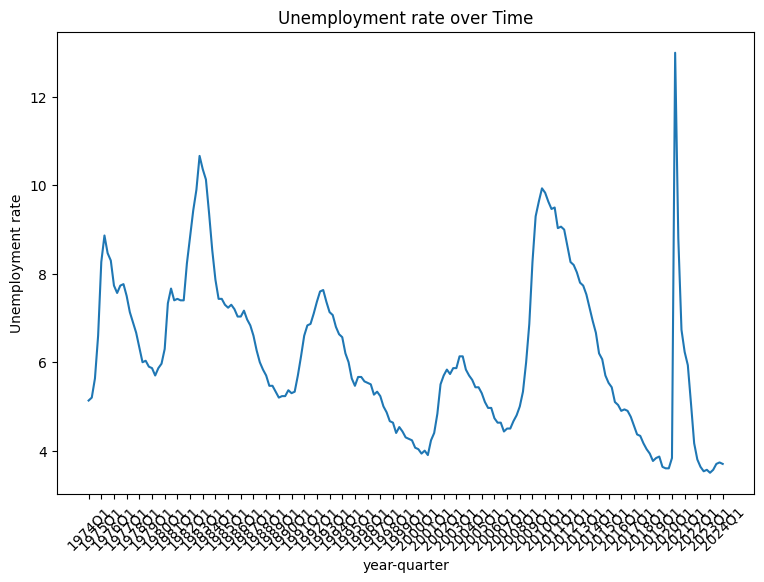

In [294]:
plt.figure(figsize=(9,6))
plt.plot(df_economy.index, df_economy["unemployment_rate"])
plt.title("Unemployment rate over Time")
plt.xlabel("year-quarter")
plt.ylabel("Unemployment rate")
plt.xticks(
    range(0, len(df_economy.index), 4),
    df_economy.index[::4],
    rotation=45
)
plt.show()

#### Unemployment changes by year

Changes in the unemployment rate fluctuate around approximately zero.

Large positive values represent periods of increasing unemployment, while negative values indicate decreases in the unemployment rate.

The largest increase occurs around 2020, whereas the largest decrease occurs around 2021.

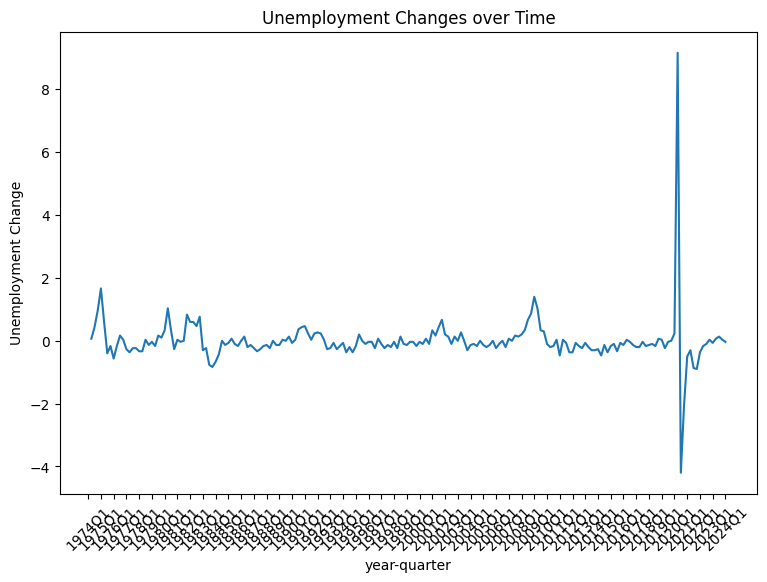

In [295]:
plt.figure(figsize=(9,6))
plt.plot(df_economy.index, df_economy["unemployment_change"])
plt.title("Unemployment Changes over Time")
plt.xlabel("year-quarter")
plt.ylabel("Unemployment Change")
plt.xticks(
    range(0, len(df_economy.index), 4),
    df_economy.index[::4],
    rotation=45
)
plt.show()

#### Unemployment changes highs and lows

In [296]:
df_economy["unemployment_change"].nsmallest()

year-quarter
2020Q3   -4.200000
2020Q4   -2.066667
2021Q4   -0.900000
2021Q3   -0.866667
1983Q4   -0.833333
Name: unemployment_change, dtype: float64

In [297]:
df_economy["unemployment_change"].nlargest()

year-quarter
2020Q2    9.166667
1975Q1    1.666667
2009Q1    1.400000
1980Q2    1.033333
2009Q2    1.033333
Name: unemployment_change, dtype: float64

#### Descriptive statistics

In [298]:
df_economy["unemployment_rate"].describe()

count    201.000000
mean       6.176783
std        1.748276
min        3.500000
25%        4.900000
50%        5.866667
75%        7.333333
max       13.000000
Name: unemployment_rate, dtype: float64

In [299]:
df_economy["unemployment_change"].describe()

count    200.000000
mean      -0.007167
std        0.805362
min       -4.200000
25%       -0.200000
50%       -0.066667
75%        0.066667
max        9.166667
Name: unemployment_change, dtype: float64

#### Boxplot

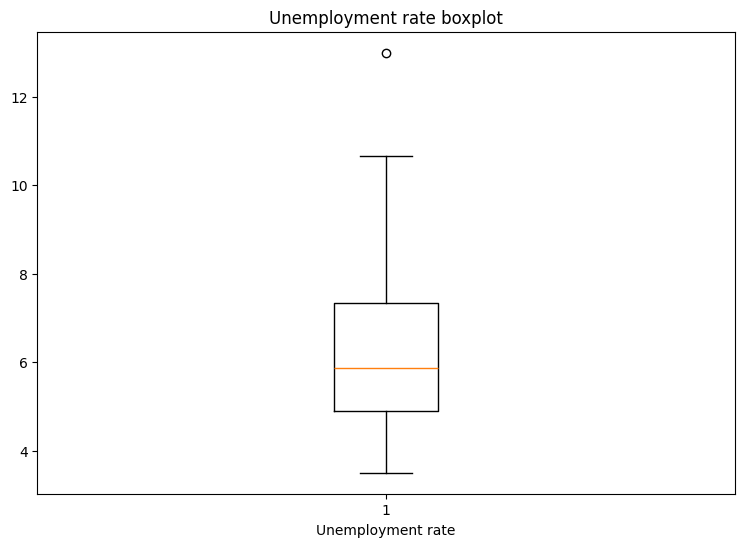

In [300]:
plt.figure(figsize=(9,6))
plt.boxplot(df_economy["unemployment_rate"])
plt.title("Unemployment rate boxplot")
plt.xlabel("Unemployment rate")
plt.show()

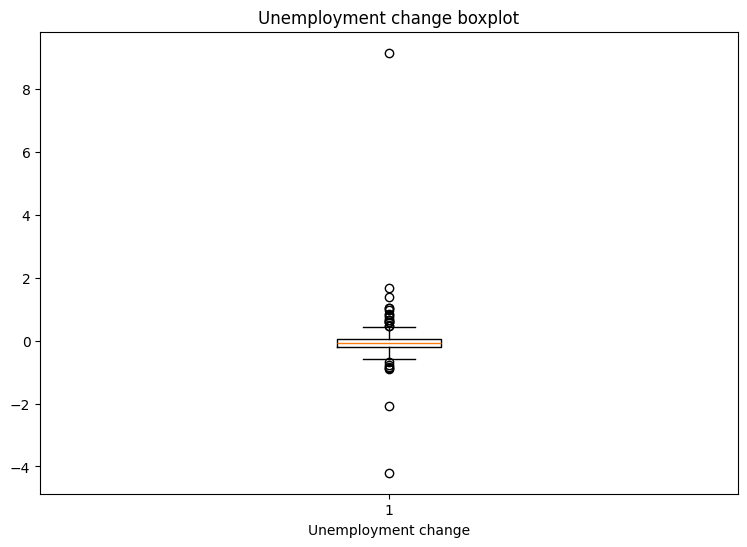

In [301]:
plt.figure(figsize=(9,6))
plt.boxplot(df_economy["unemployment_change"].dropna())
plt.title("Unemployment change boxplot")
plt.xlabel("Unemployment change")
plt.show()

## Distribution analysis

### GDP Growth

The distribution of GDP growth is centered around 0 to 0.025 and shows moderate dispersion.

The skewness value of -1.1 suggests that the distribution is left-skewed.

The presence of observations far from the center may indicate periods of unusually strong or weak economic growth.

#### Histogram

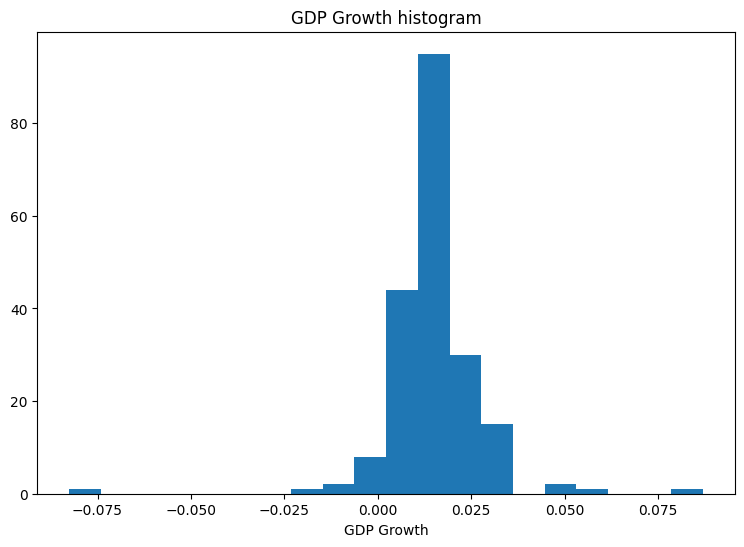

In [302]:
plt.figure(figsize=(9,6))
plt.hist(df_economy["gdp_growth"].dropna(), bins=20)
plt.title("GDP Growth histogram")
plt.xlabel("GDP Growth")
plt.show()

#### Skewness

In [303]:
df_economy["gdp_growth"].skew()

np.float64(-1.1036621822219408)

### CPI Growth

CPI growth is distributed around -0.01 to 0.03.

The skewness statistic of 0.72 indicates a right-skewed distribution.


#### Histogram

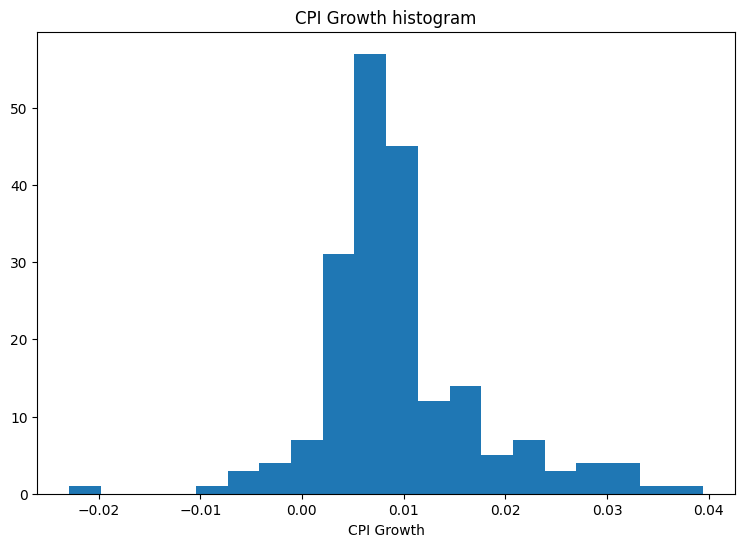

In [304]:
plt.figure(figsize=(9,6))
plt.hist(df_economy["cpi_growth"].dropna(), bins=20)
plt.title("CPI Growth histogram")
plt.xlabel("CPI Growth")
plt.show()

#### Skewness

In [305]:
df_economy["cpi_growth"].skew()

np.float64(0.7292799512715927)

### Unemployment Change

The distribution of unemployment changes is centered around 0.

Most observations appear to be concentrated around -2 to 2, while relatively large changes occur less frequently.

The skewness value of 6.8 suggests that the distribution is right skewed.

#### Histogram

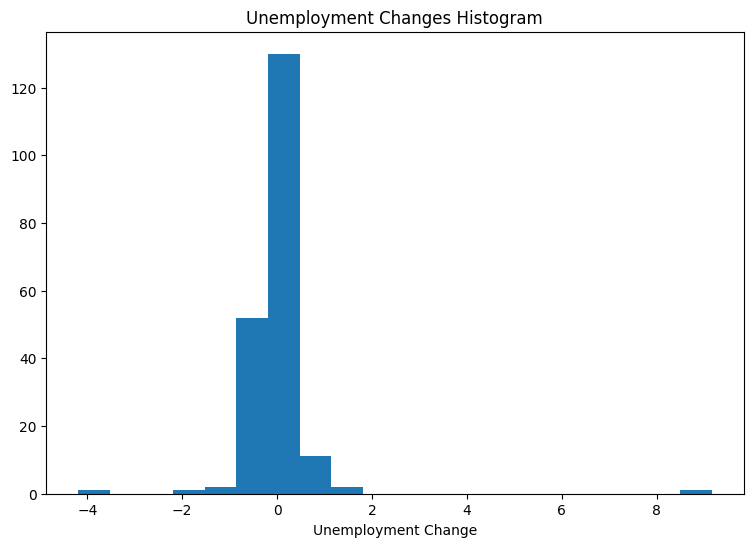

In [306]:
plt.figure(figsize=(9,6))
plt.hist(df_economy["unemployment_change"].dropna(), bins=20)
plt.title("Unemployment Changes Histogram")
plt.xlabel("Unemployment Change")
plt.show()

#### Skewness

In [307]:
df_economy["unemployment_change"].skew()

np.float64(6.8013180824751265)

## Rolling Statistics

### GDP

The 4-quarter rolling mean smooths short-term fluctuations in GDP growth and provides a clearer view of the underlying pattern.

The rolling volatility indicates that the degree of variation in GDP growth changes over time.

Periods of relatively high volatility can be observed around 2020, suggesting greater instability in economic growth during these periods.

#### Rolling mean

C:\Users\Asus\AppData\Local\Temp\ipykernel_30084\1819374039.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


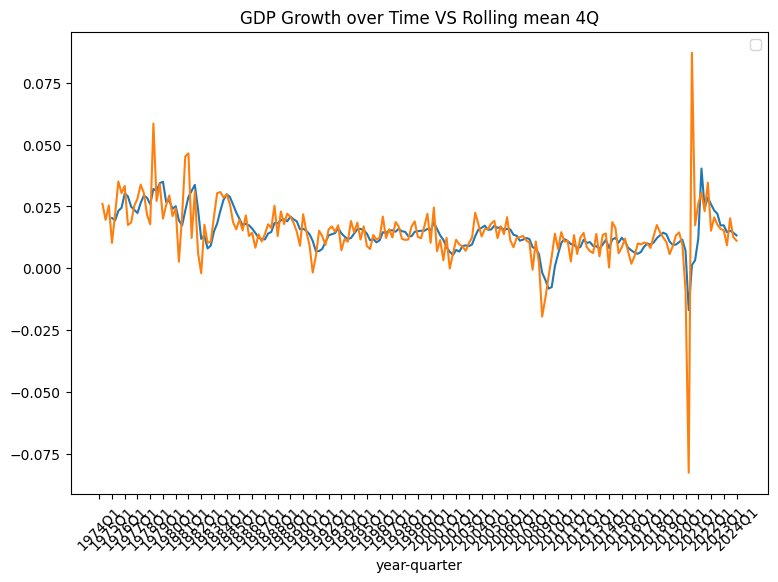

In [308]:
plt.figure(figsize=(9,6))
plt.plot(df_economy.index,df_economy["gdp_rolling_mean_4q"])
plt.plot(df_economy.index, df_economy["gdp_growth"])
plt.title("GDP Growth over Time VS Rolling mean 4Q")
plt.xlabel("year-quarter")
plt.legend()
plt.xticks(
    range(0, len(df_economy.index), 4),
    df_economy.index[::4],
    rotation=45
)
plt.show()

#### Volatility

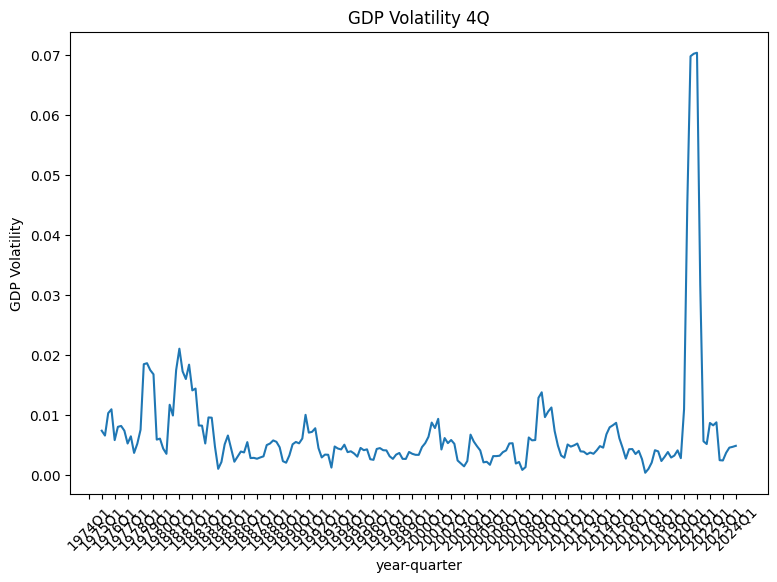

In [309]:
plt.figure(figsize=(9,6))
plt.plot(df_economy.index, df_economy["gdp_volatility_4q"])
plt.title("GDP Volatility 4Q")
plt.ylabel("GDP Volatility")
plt.xlabel("year-quarter")
plt.xticks(
    range(0, len(df_economy.index), 4),
    df_economy.index[::4],
    rotation=45
)
plt.show()

### CPI

The 4-quarter rolling mean provides a smoother view of changes in CPI growth.

The rolling volatility shows that the variability of CPI growth is not constant over time.

Higher volatility appears around 2008, while relatively stable periods can be observed around 1992 to 2000.

#### Rolling mean

C:\Users\Asus\AppData\Local\Temp\ipykernel_30084\4055429165.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


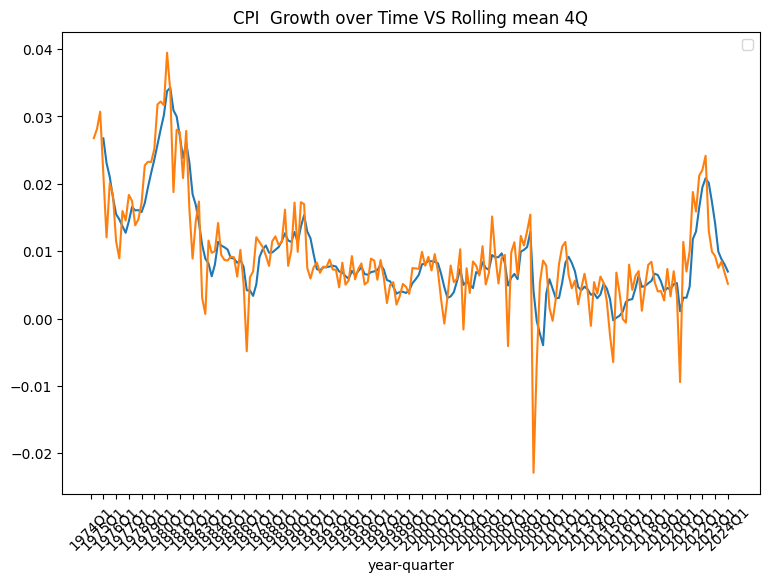

In [310]:
plt.figure(figsize=(9,6))
plt.plot(df_economy.index, df_economy["cpi_rolling_mean_4q"])
plt.plot(df_economy.index, df_economy["cpi_growth"])
plt.xlabel("year-quarter")
plt.title("CPI  Growth over Time VS Rolling mean 4Q")
plt.xticks(
    range(0, len(df_economy.index), 4),
    df_economy.index[::4],
    rotation=45
)
plt.legend()
plt.show()

#### Volatility

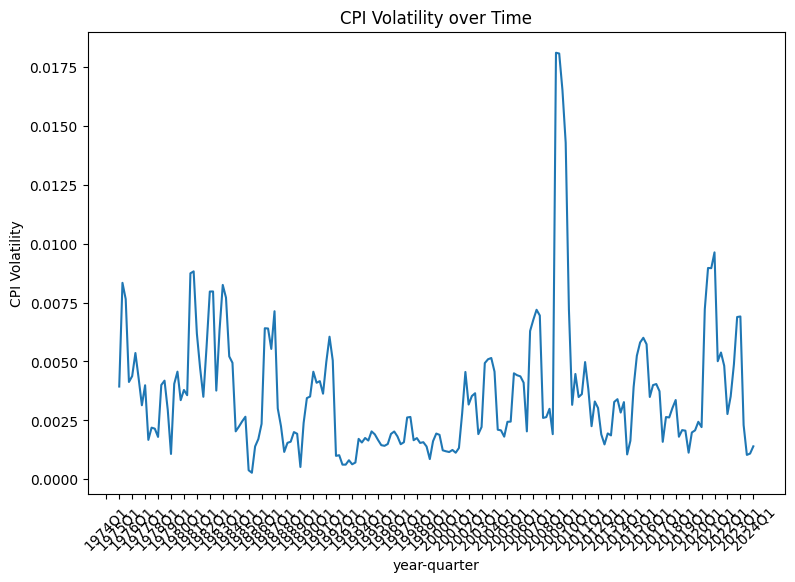

In [311]:
plt.figure(figsize=(9,6))
plt.plot(df_economy.index, df_economy["cpi_volatility_4q"])
plt.title("CPI Volatility over Time")
plt.xlabel("year-quarter")
plt.ylabel("CPI Volatility")
plt.xticks(
    range(0, len(df_economy.index), 4),
    df_economy.index[::4],
    rotation=45
)
plt.show()

### Unemployment

The 4-quarter rolling statistics help distinguish short-term changes in unemployment from broader movements in the labor market.

The rolling volatility suggests that changes in unemployment were particularly pronounced during 2020 to 2022.

This indicates that labor market conditions were not equally stable throughout the sample period.

#### Rolling mean

C:\Users\Asus\AppData\Local\Temp\ipykernel_30084\150444689.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


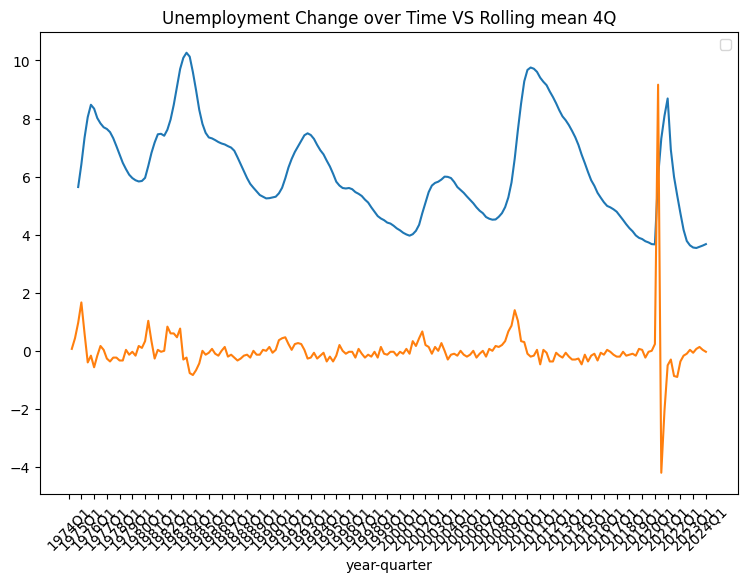

In [312]:
plt.figure(figsize=(9,6))
plt.plot(df_economy.index, df_economy["unemployment_rolling_mean_4q"])
plt.plot(df_economy.index, df_economy["unemployment_change"])
plt.title("Unemployment Change over Time VS Rolling mean 4Q")
plt.xlabel("year-quarter")
plt.xticks(
    range(0, len(df_economy.index), 4),
    df_economy.index[::4],
    rotation=45
)
plt.legend()
plt.show()


#### Volatility

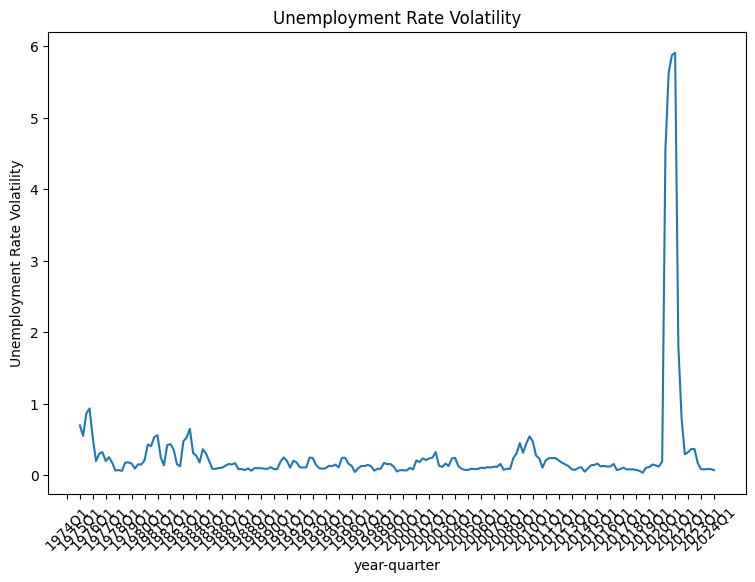

In [313]:
plt.figure(figsize=(9,6))
plt.plot(df_economy.index, df_economy["unemployment_volatility_4q"])
plt.xlabel("year-quarter")
plt.ylabel("Unemployment Rate Volatility")
plt.title("Unemployment Rate Volatility")
plt.xticks(
    range(0, len(df_economy.index), 4),
    df_economy.index[::4],
    rotation=45
)
plt.show()

## Bivariate Analysis

### GDP Growth VS Unemployment Change

The scatter plot suggests a negative relationship between GDP growth and changes in the unemployment rate.

Higher GDP growth observations are generally associated with lower changes in unemployment.

However, the scatter plot also contains outliers, indicating that the relationship is not perfectly linear.

The strength of this association is examined further using the correlation coefficient.

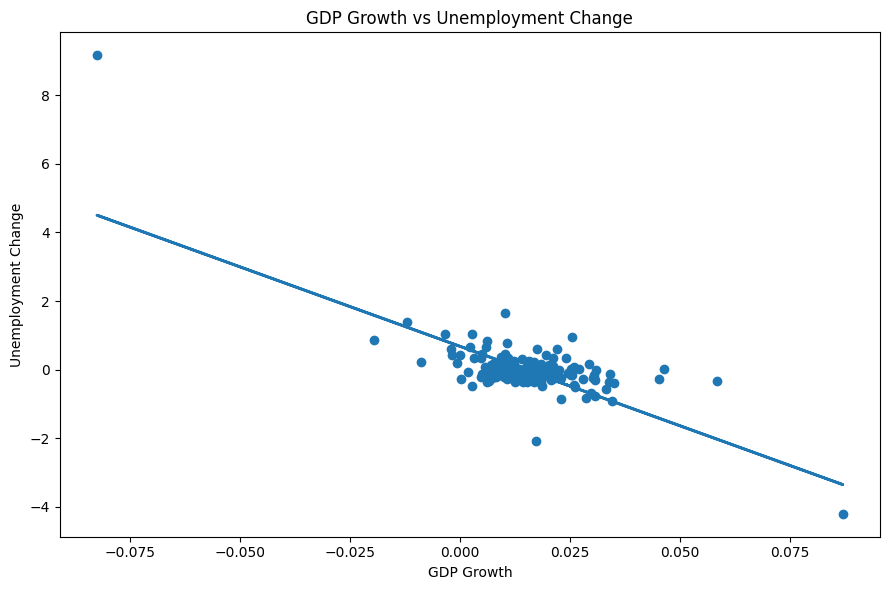

In [314]:
x = df_economy["gdp_growth"]
y = df_economy["unemployment_change"]


data = pd.concat([x, y], axis=1).dropna()

x = data["gdp_growth"]
y = data["unemployment_change"]


slope, intercept = np.polyfit(x, y, 1)


trendline = slope * x + intercept


plt.figure(figsize=(9,6))

plt.scatter(x, y)
plt.plot(x, trendline, linewidth=2)

plt.xlabel("GDP Growth")
plt.ylabel("Unemployment Change")
plt.title("GDP Growth vs Unemployment Change")

plt.tight_layout()
plt.show()

### GDP Growth VS CPI Growth

The scatter plot indicates a positive association between GDP growth and CPI growth.

The observations appear to be scattered around the general pattern.

The correlation coefficient provides a numerical measure of the strength and direction of this relationship.

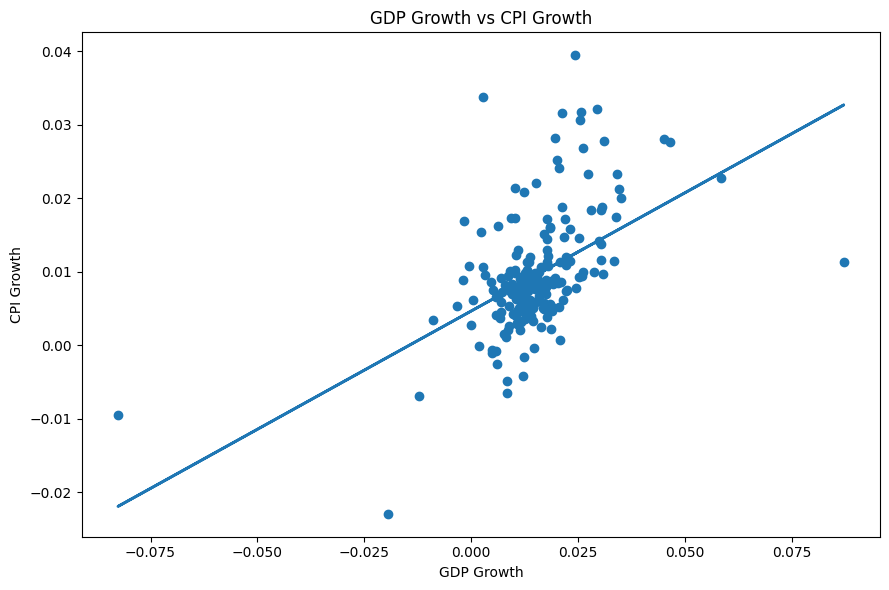

In [315]:
x = df_economy["gdp_growth"]
y = df_economy["cpi_growth"]


data = pd.concat([x, y], axis=1).dropna()

x = data["gdp_growth"]
y = data["cpi_growth"]


slope, intercept = np.polyfit(x, y, 1)


trendline = slope * x + intercept


plt.figure(figsize=(9,6))

plt.scatter(x, y)
plt.plot(x, trendline, linewidth=2)

plt.xlabel("GDP Growth")
plt.ylabel("CPI Growth")
plt.title("GDP Growth vs CPI Growth")

plt.tight_layout()
plt.show()

### CPI Growth VS Unemployment Change

The relationship between CPI growth and changes in unemployment appears to be negative/weak based on the scatter plot.

The observations are scattered distributed, suggesting that the relationship may be weak/unclear.

Further interpretation should be based on both the visual pattern and the correlation coefficient.

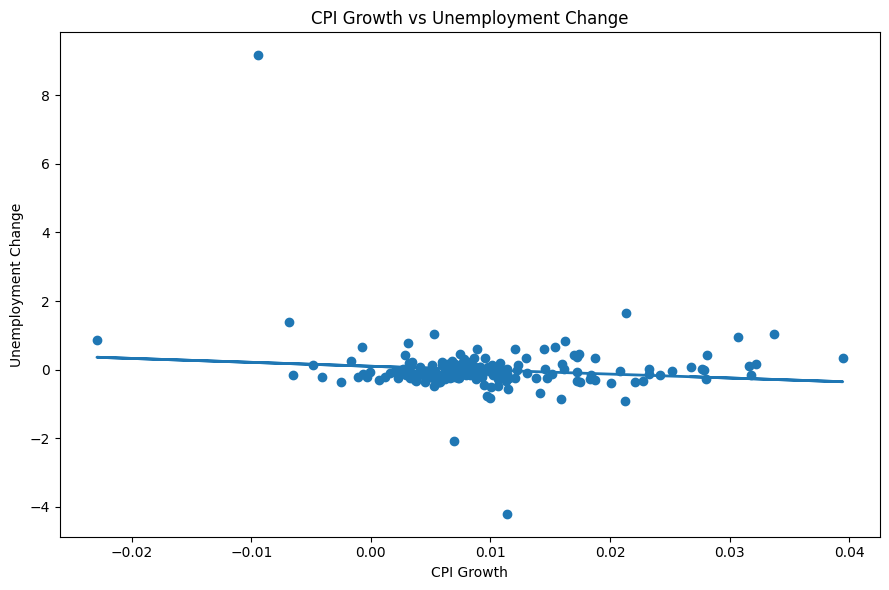

In [316]:
x = df_economy["cpi_growth"]
y = df_economy["unemployment_change"]


data = pd.concat([x, y], axis=1).dropna()

x = data["cpi_growth"]
y = data["unemployment_change"]


slope, intercept = np.polyfit(x, y, 1)


trendline = slope * x + intercept


plt.figure(figsize=(9,6))

plt.scatter(x, y)
plt.plot(x, trendline, linewidth=2)

plt.xlabel("CPI Growth")
plt.ylabel("Unemployment Change")
plt.title("CPI Growth vs Unemployment Change")

plt.tight_layout()
plt.show()

## Correlation Analysis

The correlation matrix summarizes the linear associations among GDP growth, CPI growth, and changes in the unemployment rate.

The strongest correlation is observed between GDP Growth and Unemployment Change, with a correlation coefficient of -0.73.

GDP growth and changes in unemployment show a negative association, while the relationship between CPI Growth & Unemployment rate appears weak.

These correlations describe statistical associations between the variables and should not be interpreted as evidence of causality.

In [317]:
heatmapdata = df_economy[["gdp_growth", "cpi_growth", "unemployment_change"]].corr()
heatmapdata

,gdp_growth,cpi_growth,unemployment_change
gdp_growth,1.000000,0.510459,-0.729662
cpi_growth,0.510459,1.000000,-0.113555
unemployment_change,-0.729662,-0.113555,1.000000


### Heatmap

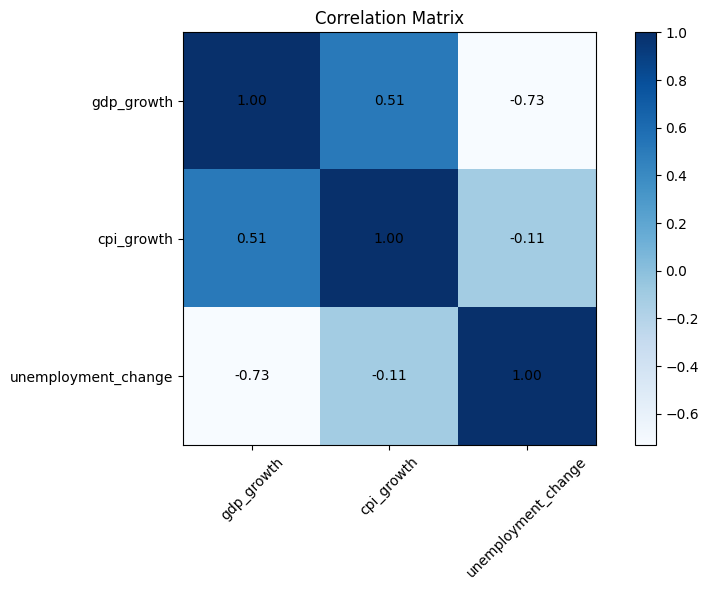

In [318]:
plt.figure(figsize=(9, 6))

plt.imshow(heatmapdata, cmap="Blues")
plt.colorbar()

plt.xticks(
    range(len(heatmapdata.columns)),
    heatmapdata.columns,
    rotation=45
)

plt.yticks(
    range(len(heatmapdata.index)),
    heatmapdata.index
)

for i in range(len(heatmapdata)):
    for j in range(len(heatmapdata.columns)):
        plt.text(
            j,
            i,
            f"{heatmapdata.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Extreme periods

The extreme observations indicate that economic conditions varied substantially across the sample period.

Some periods show particularly large movements in individual indicators, while others are characterized by simultaneous changes across multiple indicators.

These periods will be useful reference points for the economic analysis in the next stage of the project.

In [319]:
extreme_periods = pd.DataFrame({
    "Indicator": [
        "GDP Growth - Lowest",
        "GDP Growth - Highest",
        "CPI Growth - Lowest",
        "CPI Growth - Highest",
        "Unemployment Change - Lowest",
        "Unemployment Change - Highest"
    ],
    
    "Period": [
        df_economy["gdp_growth"].idxmin(),
        df_economy["gdp_growth"].idxmax(),
        df_economy["cpi_growth"].idxmin(),
        df_economy["cpi_growth"].idxmax(),
        df_economy["unemployment_change"].idxmin(),
        df_economy["unemployment_change"].idxmax()
    ],
    
    "Value": [
        df_economy["gdp_growth"].min(),
        df_economy["gdp_growth"].max(),
        df_economy["cpi_growth"].min(),
        df_economy["cpi_growth"].max(),
        df_economy["unemployment_change"].min(),
        df_economy["unemployment_change"].max()
    ]
})

extreme_periods

,Indicator,Period,Value
0,GDP Growth - Lowest,2020Q2,-0.082619
1,GDP Growth - Highest,2020Q3,0.087103
2,CPI Growth - Lowest,2008Q4,-0.022902
3,CPI Growth - Highest,1980Q1,0.039456
4,Unemployment Change - Lowest,2020Q3,-4.200000
5,Unemployment Change - Highest,2020Q2,9.166667


## Key Findings

* GDP growth shows a volatile pattern, with particularly notable fluctuations during 2020.
* CPI growth exhibits a variable pattern, with notable fluctuations around 1978, 2008, and 2020.
* Changes in the unemployment rate show noticeable short-term fluctuations throughout the sample period.
* GDP growth and changes in the unemployment rate exhibit a strong negative relationship.
* GDP growth and CPI growth show a positive association.
* Economic volatility is not constant over time, with higher volatility observed during 2020–2021.
* Several periods show simultaneous changes across multiple economic indicators, suggesting that major economic movements can affect growth, inflation, and labor market conditions at the same time.
